# TDE End-to-End Simulation

---

*Runs After*: `../notebooks/main.ipynb` (and its own upstream notebooks: `fov.ipynb`,
`skygrid.ipynb`, `skyblocks.ipynb`)
*Runs Before*: None

This notebook runs a full Monte Carlo simulation of tidal disruption events (TDEs) observed by
UVEX against the 3-year fiducial survey schedule (`preliminary_survey/initial-survey.ecsv`,
produced by `main.ipynb`), using `uvex_transient_toolkit.simulation`:

1. **Load** the fiducial schedule into a `SurveySchedule`.
2. **Sample** a Monte Carlo TDE population over the schedule's own sky footprint and time span
   (`SurveySimulator.generate_events`).
3. **Screen** that population down in two progressively more expensive passes:
   `filter_by_limiting_magnitude` (cheap, never touches the schedule) then `filter_by_snr`
   (consults the real schedule: is this event ever actually detected above a given SNR at an
   observation that really happened?).
4. **Inspect** the result: a detection funnel, the sky/redshift distribution of detected events,
   and a handful of individual light curves reconstructed via `Event.simulate_photometry`.


In [1]:
%xmode minimal
%load_ext autoreload
%autoreload 2

Exception reporting mode: Minimal


In [2]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [3]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import numpy as np
from astropy import units as u
from ligo.skymap import plot  # noqa: F401 (registers the "astro ..." projections)
from matplotlib import pyplot as plt
from regions import Regions

from astropy.table import QTable
from m4opt.missions._uvex import uvex
from uvex_transient_toolkit.simulation.core import SurveySimulator
from uvex_transient_toolkit.surveys.base import SurveySchedule
from uvex_transient_toolkit.transients.TDEs import TidalDisruptionEvent

### Configuration Settings

In [4]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- SURVEY INPUT SETTINGS --- #
# Directory containing the 3-year fiducial survey products written by ``../notebooks/main.ipynb``
# (and its own upstream notebooks) in this repository.
SURVEY_OUTPUT_PATH = Path("../preliminary_survey")
PLAN_FILE_PATH = SURVEY_OUTPUT_PATH / "initial-survey.ecsv"
# ``SurveySchedule`` only supports a Rectangle/CircleSkyRegion FOV (not the real chip-gapped
# footprint ``main.ipynb`` schedules against) -- the bounding rectangle is the appropriately
# conservative single-shape approximation for the containment queries this notebook needs
# (``SurveySchedule.get_observations_of``).
FOV_FILE_PATH = SURVEY_OUTPUT_PATH / "bounding-rectangle.ds9"

# --- OUTPUT SETTINGS --- #
OUTPUT_PATH = SURVEY_OUTPUT_PATH / "transients"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- POPULATION SETTINGS --- #
# HEALPix resolution and number of time bins ``generate_events`` samples over -- see its own
# docstring. This same NSIDE is also what ``filter_by_snr`` below queries its schedule
# coverage index at (it reuses each event's own ``healpix_id`` directly, at whatever
# resolution it was sampled at -- see that method's docstring), so it needs to be fine
# enough relative to UVEX's ~3.7 deg FOV that pixel-center-membership tracks true FOV
# containment closely: NSIDE=128 (~0.46 deg pixels, ~8x finer than the FOV) keeps that
# approximation to roughly a 0.6% chance of a wrong detect/non-detect decision, split
# roughly evenly between false positives and false negatives. Higher NSIDE / more
# TIME_BINS sample a more complete population at the cost of runtime.
NSIDE = 128
TIME_BINS = 200
SIMULATION_SEED = 42
DOWNSAMPLE = 10

# --- SCREENING SETTINGS --- #
# AB magnitude limit for the cheap, schedule-agnostic first pass (``filter_by_limiting_magnitude``).
MAG_LIMIT = 25.0
MAG_FILTER_CHUNK_SIZE = 5000

# SNR an event must clear at least once, at some real scheduled observation, to count as
# detected (``filter_by_snr``).
SNR_THRESHOLD = 5.0
SNR_FILTER_CHUNK_SIZE = 500

# --- EXAMPLE LIGHT CURVE SETTINGS --- #
N_EXAMPLE_LIGHTCURVES = 10
EXAMPLE_SEED = 0

## Load the Survey Schedule

Reads the fiducial 3-year schedule directly -- its columns (`start_time`, `duration`,
`observer_location`, `action`, `target_coord`, `roll`, `field_id`, `block_id`) already match
`SurveySchedule`'s expected schema, so no conversion is needed.

In [5]:
# ========================================= #
# Load the 3-Year Fiducial Survey Schedule  #
# ========================================= #
for _path in (PLAN_FILE_PATH, FOV_FILE_PATH):
    if not _path.exists():
        raise FileNotFoundError(
            f"File not found at {_path}. Run ../notebooks/main.ipynb (and its own upstream "
            "notebooks) first."
        )

plan = QTable.read(PLAN_FILE_PATH)
(fov,) = Regions.read(str(FOV_FILE_PATH))
schedule = SurveySchedule(plan, fov)

n_observe = int(np.count_nonzero(plan["action"] == "observe"))
print(f"{len(schedule)} scheduled actions ({n_observe} observations)")
print(
    f"Mission span: {schedule.start_time.iso} to "
    f"{(schedule.start_time + schedule.duration).iso}"
)

69663 scheduled actions (33010 observations)
Mission span: 2030-01-01 00:00:00.000 to 2032-01-01 06:10:40.983


## Set Up the TDE Population

`TidalDisruptionEvent` supplies both the SED model (`VanVelzenTDESED`) and the volumetric event
rate `SurveySimulator.generate_events` samples from -- a constant 3.1e-7 Mpc^-3 yr^-1 (Yao et al.
2023) out to z=1 by default. `SurveySimulator` ties it to the schedule loaded above.


In [6]:
# ========================================= #
# Register the TDE Population                #
# ========================================= #
tde = TidalDisruptionEvent()

# Set the basic parameters (slightly above the class default of 1, to include a modest
# high-redshift tail).
tde.redshift_limit = 2
tde.duration_limit = 500 * u.day

simulator = SurveySimulator(schedule, transients={"tde": tde}, simulation_seed=SIMULATION_SEED)

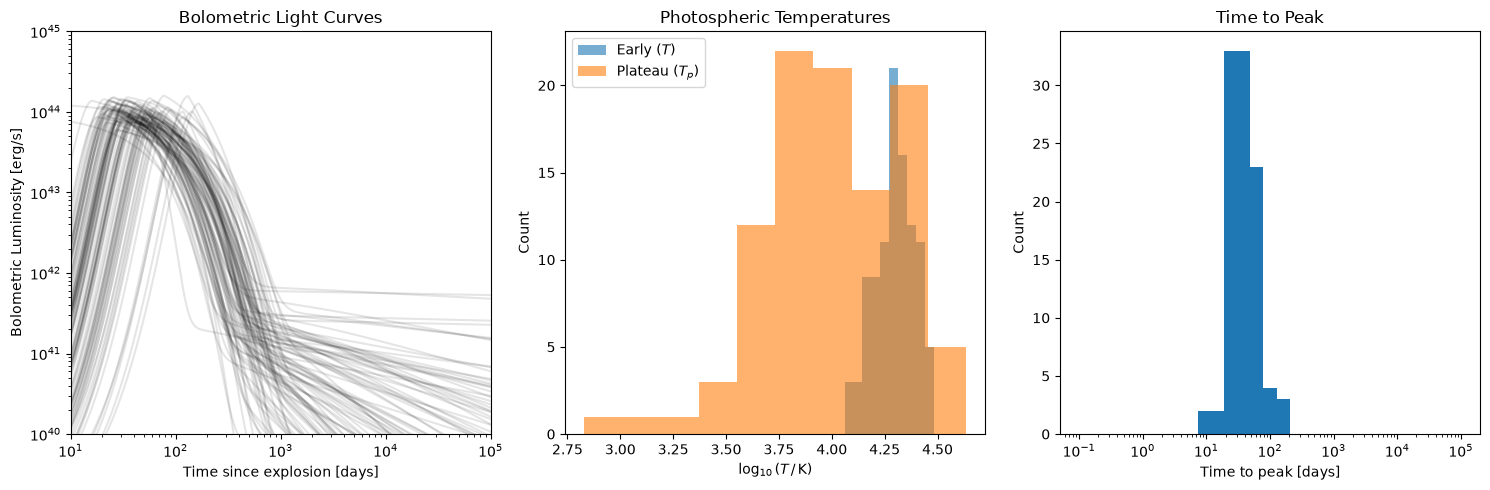

In [7]:
# Sample the population's physical parameters and inspect its shape: bolometric light curves,
# photospheric temperatures (early vs. plateau), and -- read off each curve's own numerical
# maximum, not assumed -- the distribution of time-to-peak. Time is measured since explosion
# throughout; t_peak = 5 * sigma_rise (`GREDLightcurve`'s own convention) varies event to event,
# so it is *not* an alignment axis here.
_rng = np.random.default_rng(0)
t = np.geomspace(1e-1, 1e5, 1000) * u.day

parameters = tde.sed.sample_parameters(100, rng=_rng)
L = tde.sed.eval_bolometric(t[:, np.newaxis], **parameters)
temperature = parameters["temperature"]
plateau_temperature = parameters["plateau_temperature"]
t_peak = t[np.argmax(L, axis=0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].loglog(t, L, color="k", alpha=0.1)
axes[0].set_xlabel("Time since explosion [days]")
axes[0].set_ylabel("Bolometric Luminosity [erg/s]")
axes[0].set_xlim([1e1, 1e5])
axes[0].set_ylim([1e40, 1e45])
axes[0].set_title("Bolometric Light Curves")

axes[1].hist(np.log10(temperature.cgs.value), alpha=0.6, label="Early ($T$)")
axes[1].hist(np.log10(plateau_temperature.cgs.value), alpha=0.6, label="Plateau ($T_p$)")
axes[1].set_xlabel(r"$\log_{10}(T \, / \, \mathrm{K})$")
axes[1].set_ylabel("Count")
axes[1].set_title("Photospheric Temperatures")
axes[1].legend()

axes[2].hist(t_peak.value, bins=np.logspace(-1, 5, 30))
axes[2].set_xscale("log")
axes[2].set_xlabel("Time to peak [days]")
axes[2].set_ylabel("Count")
axes[2].set_title("Time to Peak")

fig.tight_layout()

## Sample a Monte Carlo TDE Population

`generate_events` samples explosion times, positions, redshifts, and per-event physical
parameter seeds only within the HEALPix pixels and time bins the survey could plausibly have
caught an event in -- see its own docstring for exactly how `luminosity_distance`/`ebv` get
cached here too.

In [8]:
# ========================================= #
# Sample a Monte Carlo TDE Population         #
# ========================================= #
catalog = simulator.generate_events(time_bins=TIME_BINS, nside=NSIDE, downsample=DOWNSAMPLE)
print(f"Sampled {len(catalog)} TDEs across {TIME_BINS} time bin(s) at NSIDE={NSIDE}.")
print(f"Corrected for downsampling, we sample {len(catalog)*DOWNSAMPLE} events.")

Generating events:   0%|          | 0/200 [00:00<?, ?bin/s]

Sampled 12480 TDEs across 200 time bin(s) at NSIDE=128.
Corrected for downsampling, we sample 124800 events.


## Screen: Ever Bright Enough?

`filter_by_limiting_magnitude` never touches the schedule -- it only asks whether an event could
ever clear `MAG_LIMIT` over its own duration, using a shared phase grid. A freshly sampled
catalog is typically dominated by events far too faint to ever matter, so this cheap pass runs
first.

In [9]:
# ========================================= #
# Screen: Ever Bright Enough?                 #
# ========================================= #
mag_filtered = simulator.filter_by_limiting_magnitude(
    catalog,
    uvex,
    mag_limit=MAG_LIMIT,
    chunk_size=MAG_FILTER_CHUNK_SIZE,
)
print(f"{len(mag_filtered)} of {len(catalog)} TDEs could ever clear {MAG_LIMIT} AB mag.")
print(f"Corrected for downsampling, we sample {len(mag_filtered)*DOWNSAMPLE} events.")

Filtering by mag limit:   0%|          | 0/3 [00:00<?, ?chunk/s]

3464 of 12480 TDEs could ever clear 25.0 AB mag.
Corrected for downsampling, we sample 34640 events.


## Screen: Actually Detected by the Schedule?

`filter_by_snr` asks the real question: over every observation the schedule actually made of an
event's position while it was active, is it ever detected above `SNR_THRESHOLD`? Unlike the
magnitude cut above, this *does* consult the schedule -- via a fast HEALPix-pixel coverage index
(`SurveySchedule.get_healpix_coverage_index`, queried per event via
`SurveySchedule.get_observation_indices_of`) built once, on first use, and cached: about a
second to index the whole 3-year schedule, then a cheap lookup per event, queried at each event's
own `healpix_id` -- the same grid `NSIDE` samples the population on (see the config cell above for
why that resolution matters here too). That index trades a small amount of geometric precision for
speed -- pixel-*center* membership rather than exact FOV polygon containment -- so a small fraction
of events (roughly 0.6% at `NSIDE=128`) end up with a different detect/non-detect decision than the
exact geometric test would give, split roughly evenly between false positives and false negatives.


In [10]:
# ========================================= #
# Screen: Actually Detected by the Schedule?  #
# ========================================= #
detected = simulator.filter_by_snr(
    mag_filtered,
    uvex,
    snr_threshold=SNR_THRESHOLD,
    chunk_size=SNR_FILTER_CHUNK_SIZE,
)
print(f"{len(detected)} of {len(mag_filtered)} TDEs were detected above SNR={SNR_THRESHOLD}.")
print(f"Corrected for downsampling, we sample {len(detected)*DOWNSAMPLE} events.")

Filtering by SNR:   0%|          | 0/7 [00:00<?, ?chunk/s]

1603 of 3464 TDEs were detected above SNR=5.0.
Corrected for downsampling, we sample 16030 events.


## Detection Summary

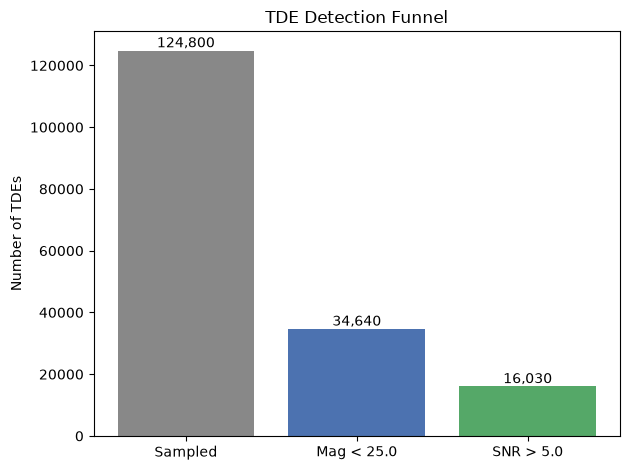

In [11]:
# ========================================= #
# Detection Funnel                            #
# ========================================= #
_stages = ["Sampled", f"Mag < {MAG_LIMIT}", f"SNR > {SNR_THRESHOLD}"]
_counts = [len(catalog)*DOWNSAMPLE, len(mag_filtered)*DOWNSAMPLE, len(detected)*DOWNSAMPLE]

fig, ax = plt.subplots()
ax.bar(_stages, _counts, color=["#888888", "#4C72B0", "#55A868"])
for i, c in enumerate(_counts):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom")
ax.set_ylabel("Number of TDEs")
ax.set_title("TDE Detection Funnel")
fig.tight_layout()

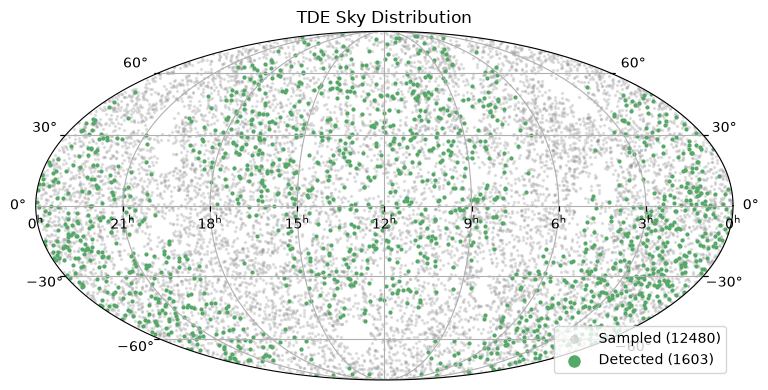

In [12]:
# ========================================= #
# Sky Distribution                            #
# ========================================= #
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection="astro hours mollweide")
ax.grid()
_transform = ax.get_transform("world")
ax.scatter(
    catalog.coord.ra.deg,
    catalog.coord.dec.deg,
    transform=_transform,
    s=2,
    alpha=0.2,
    color="#888888",
    label=f"Sampled ({len(catalog)})",
)
ax.scatter(
    detected.coord.ra.deg,
    detected.coord.dec.deg,
    transform=_transform,
    s=4,
    color="#55A868",
    label=f"Detected ({len(detected)})",
)
ax.legend(loc="lower right", markerscale=4)
ax.set_title("TDE Sky Distribution")
fig.tight_layout()

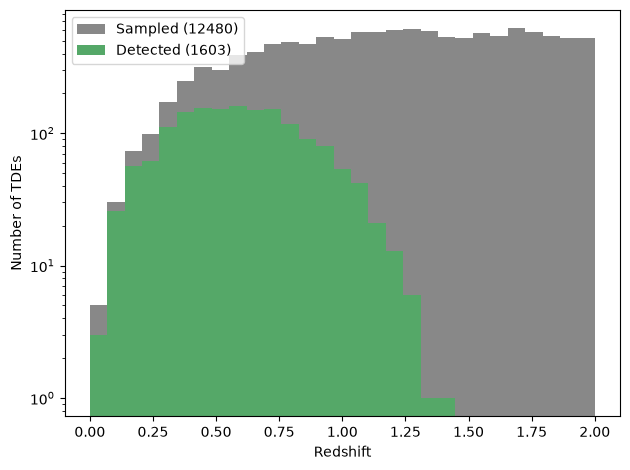

In [13]:
# ========================================= #
# Redshift Distribution                       #
# ========================================= #
_bins = np.linspace(0, catalog.redshift.max(), 30)
fig, ax = plt.subplots()
ax.hist(catalog.redshift, bins=_bins, color="#888888", label=f"Sampled ({len(catalog)})")
ax.hist(detected.redshift, bins=_bins, color="#55A868", label=f"Detected ({len(detected)})")
ax.set_yscale("log")
ax.set_xlabel("Redshift")
ax.set_ylabel("Number of TDEs")
ax.legend()
fig.tight_layout()

## Example Light Curves

Reconstructs a handful of detected events as real `Event` objects (`EventCatalog.get_events`)
and runs full synthetic photometry (`Event.simulate_photometry`) against every observation the
schedule actually made of each one.

In [14]:
# ========================================= #
# Reconstruct a Few Detected Events           #
# ========================================= #
_rng = np.random.default_rng(EXAMPLE_SEED)
_example_ids = _rng.choice(
    detected.event_id, size=min(N_EXAMPLE_LIGHTCURVES, len(detected)), replace=False
)
example_events = detected.get_events(_example_ids, {"tde": tde}, schedule)

for event in example_events:
    print(event)

<Event id=10828 type='tde' z=0.5137 n_observations=12>
<Event id=10453 type='tde' z=0.5125 n_observations=1>
<Event id=8218 type='tde' z=1.04 n_observations=2>
<Event id=6425 type='tde' z=0.1346 n_observations=6>
<Event id=3403 type='tde' z=0.6006 n_observations=80>
<Event id=517 type='tde' z=0.4113 n_observations=16>
<Event id=215 type='tde' z=0.6541 n_observations=6>
<Event id=3874 type='tde' z=0.8013 n_observations=6>
<Event id=2344 type='tde' z=0.3762 n_observations=9>
<Event id=1005 type='tde' z=0.7082 n_observations=19>


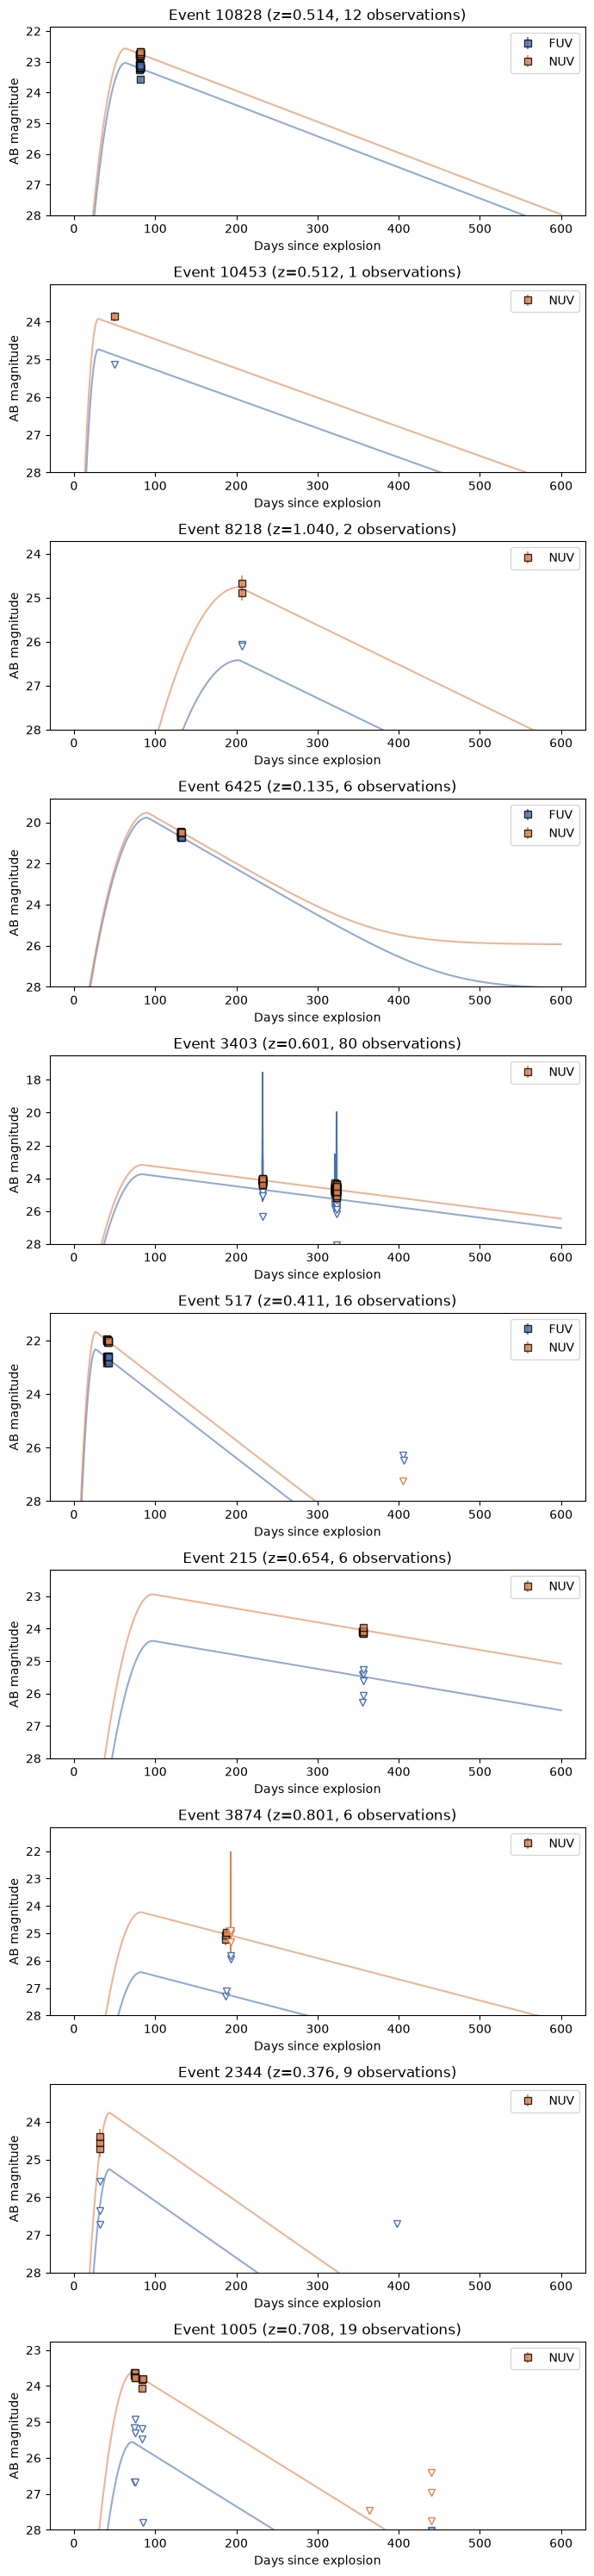

In [15]:
# ========================================= #
# Plot Light Curves                           #
# ========================================= #
_band_colors = {"FUV": "#4C72B0", "NUV": "#DD8452"}

fig, axes = plt.subplots(
    len(example_events), 1, figsize=(7, 3 * len(example_events)), squeeze=False
)
for ax, event in zip(axes[:, 0], example_events):
    phot = event.simulate_photometry(uvex)
    t_since_explosion = (phot["obs_time"] - event.t_explosion).to(u.day)

    t_array = np.linspace(0, 600, 300) * u.day

    for band, color in _band_colors.items():
        # Theory curve: the true (noiseless) magnitude vs. time -- Event.mag reuses
        # this event's own redshift/luminosity_distance/dust/SED parameters
        # automatically, and matches simulate_photometry's own noiseless mean exactly
        # (same pivot-wavelength definition, see its docstring).
        mag_theory = event.mag(t_array, uvex, band=band)
        ax.plot(t_array.value, mag_theory.value, color=color, lw=1.5, alpha=0.6)

        selected = (
            np.isfinite(phot["ab_mag"]) & (phot["band"] == band) & (phot["snr"] > 5)
        )
        non_detected = (
            np.isfinite(phot["ab_mag"]) & (phot["band"] == band) & (phot["snr"] <= 5)
        )

        # Each marker kind is only ever drawn if it actually has points -- an empty
        # `selected` (no confident detections in this band) used to `continue` past
        # the `non_detected` errorbar call below too, hiding real non-detections.
        if np.any(selected):
            ax.errorbar(
                t_since_explosion[selected].value,
                phot["ab_mag"][selected],
                yerr=phot["mag_err"][selected],
                mfc=color,
                mec="k",
                ecolor=color,
                marker="s",
                linestyle="none",
                alpha=0.8,
                label=band,
            )
        if np.any(non_detected):
            ax.errorbar(
                t_since_explosion[non_detected].value,
                phot["ab_mag"][non_detected],
                yerr=[phot["mag_upper"][non_detected] - phot["ab_mag"][non_detected],
                      np.abs(phot["mag_lower"][non_detected] - phot["ab_mag"][non_detected])],
                marker="v",
                mec=color,
                mfc="w",
                ecolor=color,
                linestyle="none",
            )

    ax.invert_yaxis()
    ax.set_xlabel("Days since explosion")
    ax.set_ylabel("AB magnitude")
    ax.set_title(
        f"Event {event.event_id} (z={event.redshift:.3f}, "
        f"{event.n_observations} observations)"
    )
    ax.legend()


for ax in axes.flatten():
    ax.set_ylim([28, None])
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "tde_example_lightcurves.png")

## Save the Detected Catalog

In [16]:
# ========================================= #
# Save the Detected Catalog                   #
# ========================================= #
_catalog_path = OUTPUT_PATH / "tde_detected_catalog.ecsv"
detected.to_disk(_catalog_path, overwrite=True)
print(f"Wrote {len(detected)} detected TDEs to {_catalog_path}")

Wrote 1603 detected TDEs to ../preliminary_survey/transients/tde_detected_catalog.ecsv


# Plateau Phase Observability

In this section of the notebook, we ask a slightly different flavor of question: out to what redshift can UVEX detect TDEs on their plateau? To do this, we're going to perform a simple Monte Carlo draw for TDE redshift and parameters. Then ask a simple question:

> In how many of these draws is the TDE brighter than 25th magnitude in either NUV or FUV after > 2 years post peak? How many plateau-visible TDEs do we predict to have during the prime mission duration given the volumetric rate and our empirical detection fraction?

In [17]:
SAMPLE_SIZE = 100_000
TDE_PARAMETERS = tde.sed.sample_parameters(SAMPLE_SIZE, rng=_rng)
TDE_REDSHIFTS = tde.sample_event_redshift(SAMPLE_SIZE, rng=_rng)

TDE_PARAMETERS = {
    _k: _v[np.newaxis,:] for _k,_v in TDE_PARAMETERS.items()
}

# Generate an array of times from 2 years post-peak to 5 years post-peak.
TIME_ARRAY = np.linspace(2 * u.year, 5 * u.year, 5)

# Evaluate the TDE magnitudes at these times for each sampled TDE.
TDE_MAGS = tde.sed.mag_bandpass(uvex.detector.bandpasses['NUV'],
                                TIME_ARRAY[:,np.newaxis],
                                redshift  = TDE_REDSHIFTS[np.newaxis,:],
                                **TDE_PARAMETERS)

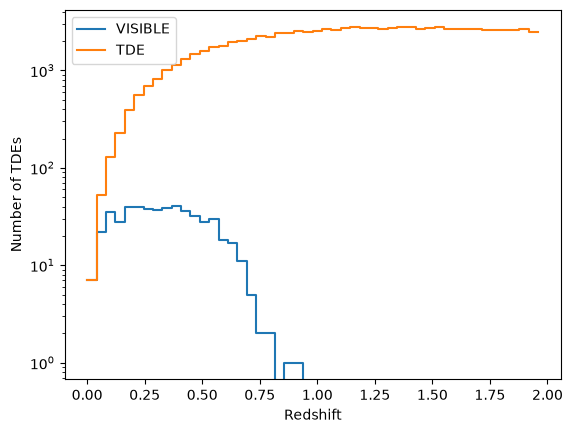

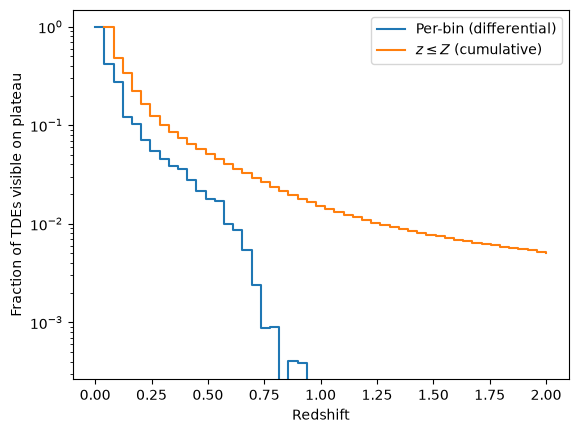

In [47]:
LIMIT_MASK = (TDE_MAGS.value < 25).any(axis=0)

# Bin into redshift ranges to see how many TDEs are visible in each bin.
bins = np.linspace(0, 2, 50)
N_TDE = np.histogram(TDE_REDSHIFTS, bins=bins)[0]
N_VISIBLE = np.histogram(TDE_REDSHIFTS[LIMIT_MASK], bins=bins)[0]

# Cumulative version: fraction of TDEs with z <= Z that are visible on plateau, at each
# bin's right edge Z -- running sums of the same per-bin counts above, so this stays
# consistent with N_TDE/N_VISIBLE rather than re-deriving from TDE_REDSHIFTS/LIMIT_MASK.
CUM_N_TDE = np.cumsum(N_TDE)
CUM_N_VISIBLE = np.cumsum(N_VISIBLE)
CUM_FRACTION = CUM_N_VISIBLE / CUM_N_TDE

# plot the fraction.
fig, ax = plt.subplots()
plt.plot(bins[:-1], N_VISIBLE,drawstyle='steps-post', label="VISIBLE")
plt.plot(bins[:-1], N_TDE,drawstyle='steps-post', label="TDE")
plt.yscale('log')
ax.legend()
ax.set_ylabel("Number of TDEs")
ax.set_xlabel("Redshift")

fig, ax = plt.subplots()
plt.plot(bins[:-1], N_VISIBLE / N_TDE, drawstyle='steps-post', label='Per-bin (differential)')
plt.plot(bins[1:], CUM_FRACTION, drawstyle='steps-post', label=r'$z \leq Z$ (cumulative)')
plt.xlabel("Redshift")
plt.ylabel("Fraction of TDEs visible on plateau")
plt.yscale('log')
plt.legend()
plt.show()

## Fit the Plateau-Visible Fraction

The binned Monte Carlo fraction above is noisy at high redshift, where plateau visibility is rare
and few of the `SAMPLE_SIZE` draws land in each bin. Model it as a simple exponential decay in
redshift -- linear in log space, $\log_{10} P(z) = \log_{10} P_0 - \alpha z$ -- fit by weighted
least squares against the binned fraction, and use the fit (rather than the raw noisy bins) below
to extrapolate smoothly out to `tde.redshift_limit`.

log10(P) = -0.393 - 2.768 * z


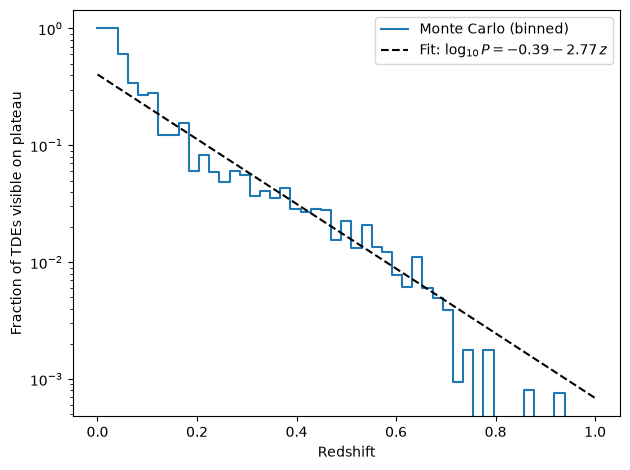

In [19]:
# ========================================= #
# Fit log10(P) = log_P0 - alpha * z            #
# ========================================= #
# Weighted least squares in log10(fraction) vs. redshift (bin centers), weighting by
# sqrt(N_VISIBLE) (a Poisson counting weight) so well-sampled bins dominate. Bins with
# zero visible TDEs are dropped -- log10(0) is undefined, and at SAMPLE_SIZE=100,000
# those bins are exactly the small-number-noise ones the fit is meant to smooth over.
bin_centers = 0.5 * (bins[:-1] + bins[1:])
fit_mask = (N_TDE > 0) & (N_VISIBLE > 0)

FRACTION = N_VISIBLE[fit_mask] / N_TDE[fit_mask]
LOG_FRACTION = np.log10(FRACTION)
FIT_WEIGHTS = np.sqrt(N_VISIBLE[fit_mask])

_neg_alpha, LOG_P0 = np.polyfit(bin_centers[fit_mask], LOG_FRACTION, deg=1, w=FIT_WEIGHTS)
ALPHA = -_neg_alpha
print(f"log10(P) = {LOG_P0:.3f} - {ALPHA:.3f} * z")


def plateau_visible_fraction(z):
    """Fitted plateau-visible fraction P(z) = 10**(LOG_P0 - ALPHA * z)."""
    return 10 ** (LOG_P0 - ALPHA * np.asarray(z))


fig, ax = plt.subplots()
ax.plot(bins[:-1], N_VISIBLE / N_TDE, drawstyle="steps-post", label="Monte Carlo (binned)")
_z_fit = np.linspace(0, bins[-1], 200)
ax.plot(
    _z_fit,
    plateau_visible_fraction(_z_fit),
    color="k",
    ls="--",
    label=rf"Fit: $\log_{{10}} P = {LOG_P0:.2f} - {ALPHA:.2f}\,z$",
)
ax.set_xlabel("Redshift")
ax.set_ylabel("Fraction of TDEs visible on plateau")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()

## Expected Number of Plateau-Visible TDEs

Convolve the fitted plateau-visible fraction $P(z)$ with the volumetric TDE rate to get an
expected count: integrate $R(z)\,(dV_c/dz)/(1+z) \cdot P(z)$ over redshift (the same
comoving-volume, $(1+z)$ time-dilation-corrected rate density
`TransientBase._ensure_rate_table` builds internally, just weighted by $P(z)$ here), then scale by
sky solid angle and the prime mission duration.

This section's Monte Carlo draws redshift and SED parameters directly from `tde`, independent of
sky position or the actual survey footprint, so there's no footprint-restricted rate available to
use here -- the whole sky ($4\pi$ sr) is assumed, making this an upper bound on what a
footprint-limited estimate would give.

In [20]:
# ========================================= #
# Convolve With the Volumetric TDE Rate        #
# ========================================= #
PRIME_MISSION_DURATION = 2 * u.year
SOLID_ANGLE = 4 * np.pi * u.sr

Z_GRID = np.linspace(0.0, tde.redshift_limit, 2000)
RATE = np.asarray(tde.event_rate(Z_GRID), dtype=float)  # events / Mpc^3 / yr
DVC_DZ = tde.cosmology.differential_comoving_volume(Z_GRID).to_value(u.Mpc**3 / u.sr)
VISIBLE_RATE_DENSITY = RATE * DVC_DZ / (1.0 + Z_GRID) * plateau_visible_fraction(Z_GRID)

INTEGRATED_VISIBLE_RATE = np.trapezoid(VISIBLE_RATE_DENSITY, Z_GRID) / (u.sr * u.yr)
N_PLATEAU_VISIBLE = (INTEGRATED_VISIBLE_RATE * SOLID_ANGLE * PRIME_MISSION_DURATION).to_value(
    u.dimensionless_unscaled
)

print(
    f"Expected plateau-visible TDEs over the whole sky in the "
    f"{PRIME_MISSION_DURATION.to_value(u.year):.0f}-year prime mission: {N_PLATEAU_VISIBLE:.1f}"
)

Expected plateau-visible TDEs over the whole sky in the 2-year prime mission: 974.3
